Universidad Torcuato Di Tella

Licenciatura en Tecnología Digital\
**Tecnología Digital VI: Inteligencia Artificial**

Importamos librerias

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

Definimos una transformación simple para imágenes RGB

In [2]:
transform = transforms.Compose([
    transforms.ToTensor() #ToTensor ya normaliza a valores en [0,1]
])

Para esta prueba vamos a utilizar el dataset MNIST

In [3]:
train_set = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_set = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
targets_ = train_set.targets

train_idx, val_idx = train_test_split(np.arange(len(targets_)), test_size = 0.2, stratify = targets_)
train_sampler = torch.utils.data.SubsetRandomSampler(train_idx)
val_sampler = torch.utils.data.SubsetRandomSampler(val_idx)

train_loader = DataLoader(train_set, sampler=train_sampler, batch_size=64)
val_loader = DataLoader(train_set, sampler=val_sampler, batch_size=64)
test_loader = DataLoader(test_set, batch_size=64)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 504kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.66MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.5MB/s]


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Arquitectura del Autoencoder

In [5]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()

        # Encoder
        self.enc_conv1 = nn.Conv2d(1, 16, 3, padding=1, stride=1)  # entrada: 28x28x1 salida: 28x28x16
        self.pool1 = nn.MaxPool2d(2, 2)  # salida: 14x14x16
        self.enc_conv2 = nn.Conv2d(16, 32, 3, padding=1, stride=1)  # salida: 14x14x32
        self.pool2 = nn.MaxPool2d(2, 2)  # salida: 7x7x32
        self.enc_conv3 = nn.Conv2d(32, 32, 3, padding=1, stride=1)  # salida: 7x7x32

        # Decoder
        self.dec_conv1 = nn.ConvTranspose2d(32, 32, 2, stride=2)  # entrada: 7x7x32 salida: 14x14x32
        self.dec_conv2 = nn.ConvTranspose2d(32, 16, 2, stride=2)  # entrada: 14x14x32 salida: 28x28x16
        self.dec_conv3 = nn.ConvTranspose2d(16, 1, 3, padding=1)  # entrada: 28x28x16 salida: 28x28x1

    def forward_encoder(self, x):
        x = F.relu(self.enc_conv1(x))
        x = self.pool1(x)
        x = F.relu(self.enc_conv2(x))
        x = self.pool2(x)
        x = F.relu(self.enc_conv3(x))
        return x

    def forward_decoder(self, x):
        x = F.relu(self.dec_conv1(x))
        x = F.relu(self.dec_conv2(x))
        x = torch.sigmoid(self.dec_conv3(x))
        return x

    def forward(self, x):
        x = self.forward_encoder(x)
        x = self.forward_decoder(x)
        return x

autoencoder = Autoencoder().to(device)

Definimos función de pérdida y optimizador

In [6]:
criterion = nn.MSELoss().to(device)
optimizer = torch.optim.SGD(autoencoder.parameters(), lr=0.01, momentum=0.9)

Entrenamos

In [7]:
num_epochs = 20

for epoch in range(num_epochs):
  train_loss = []
  val_loss = []



  for data in train_loader:
    imgs, labels = data
    imgs = imgs.to(device)
    outputs = autoencoder(imgs)
    loss = criterion(outputs, imgs) # Comparar la imagen reconstruida con la original
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    train_loss.append(loss.item() * imgs.size(0))


  with torch.no_grad():
    for data_val in val_loader:
      imgs_val, labels_val = data_val
      imgs_val = imgs_val.to(device)
      outputs_val = autoencoder(imgs_val)
      loss_val = criterion(outputs_val, imgs_val) # Comparar la imagen reconstruida con la original
      val_loss.append(loss_val.item() * imgs_val.size(0))



  print(f'Epoch: {epoch+1}, Train Loss: {np.mean(train_loss):.4f}, Val Loss: {np.mean(val_loss):.4f}')

Epoch: 1, Train Loss: 6.2988, Val Loss: 6.1413
Epoch: 2, Train Loss: 6.1248, Val Loss: 6.0912
Epoch: 3, Train Loss: 6.0509, Val Loss: 5.9301
Epoch: 4, Train Loss: 3.9536, Val Loss: 2.0630
Epoch: 5, Train Loss: 1.5717, Val Loss: 1.2122
Epoch: 6, Train Loss: 1.0129, Val Loss: 0.8604
Epoch: 7, Train Loss: 0.7740, Val Loss: 0.6966
Epoch: 8, Train Loss: 0.6453, Val Loss: 0.5979
Epoch: 9, Train Loss: 0.5641, Val Loss: 0.5318
Epoch: 10, Train Loss: 0.5101, Val Loss: 0.4871
Epoch: 11, Train Loss: 0.4713, Val Loss: 0.4539
Epoch: 12, Train Loss: 0.4417, Val Loss: 0.4272
Epoch: 13, Train Loss: 0.4180, Val Loss: 0.4068
Epoch: 14, Train Loss: 0.3987, Val Loss: 0.3886
Epoch: 15, Train Loss: 0.3824, Val Loss: 0.3737
Epoch: 16, Train Loss: 0.3685, Val Loss: 0.3608
Epoch: 17, Train Loss: 0.3564, Val Loss: 0.3497
Epoch: 18, Train Loss: 0.3459, Val Loss: 0.3397
Epoch: 19, Train Loss: 0.3366, Val Loss: 0.3312
Epoch: 20, Train Loss: 0.3282, Val Loss: 0.3241


Observemos los resultados con algunas imágenes de train

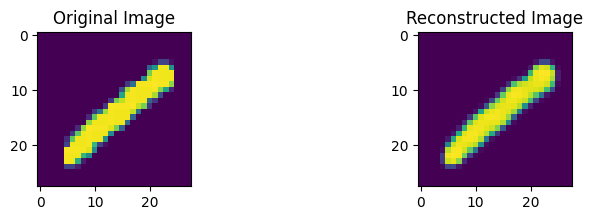

torch.Size([32, 7, 7])
tensor([[0.0000, 0.0634, 0.0877,  ..., 0.0000, 0.1595, 0.1535]],
       device='cuda:0')


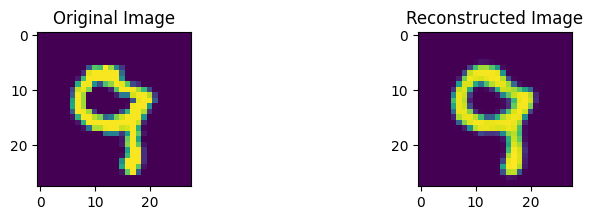

torch.Size([32, 7, 7])
tensor([[0.0000, 0.0000, 0.0000,  ..., 1.1029, 0.0000, 0.0000]],
       device='cuda:0')


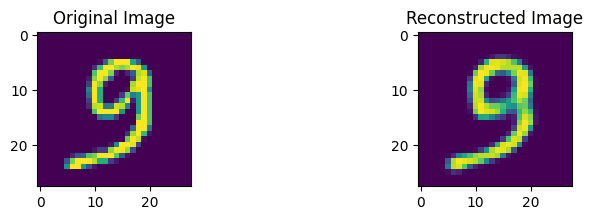

torch.Size([32, 7, 7])
tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0661]],
       device='cuda:0')


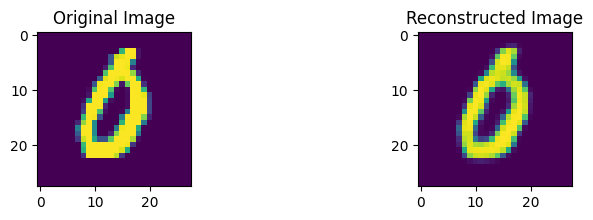

torch.Size([32, 7, 7])
tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.1408]],
       device='cuda:0')


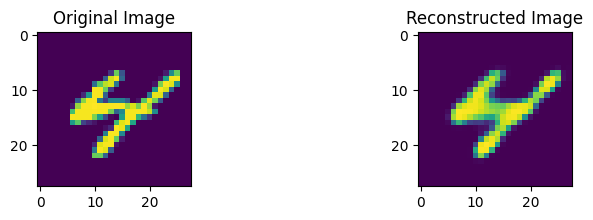

torch.Size([32, 7, 7])
tensor([[0.0000, 0.0694, 0.0000,  ..., 0.0000, 0.0816, 0.1535]],
       device='cuda:0')


In [8]:
train_iter = iter(train_loader)
imgs, labels = next(train_iter)
imgs = imgs.to(device)

with torch.no_grad():
    outputs = autoencoder(imgs)
    latent_space = autoencoder.forward_encoder(imgs)

imgs = imgs.cpu().numpy()
outputs = outputs.cpu().numpy()

num_imgs = 5
for i in range(num_imgs):
    original_image = np.transpose(imgs[i], (1, 2, 0))
    reconstructed_image = np.transpose(outputs[i], (1, 2, 0))


    # Mostrar la imagen original
    plt.figure(figsize=(9, 2))
    plt.subplot(1, 2, 1)
    plt.imshow(original_image, interpolation='none')
    plt.title('Original Image')

    # Mostrar la imagen reconstruida
    plt.subplot(1, 2, 2)
    plt.imshow(reconstructed_image, interpolation='none')
    plt.title('Reconstructed Image')

    plt.show()

    print(latent_space[i].shape)
    print(latent_space[i].view(1, -1))


Observemos los resultados con algunas imágenes de test

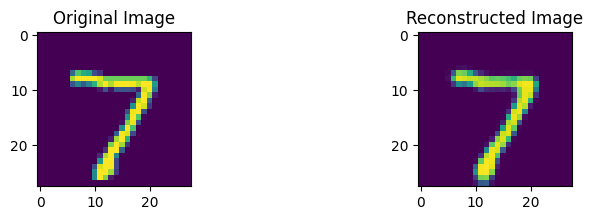

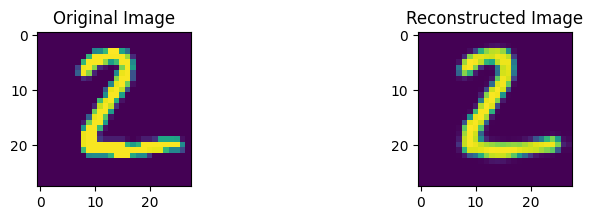

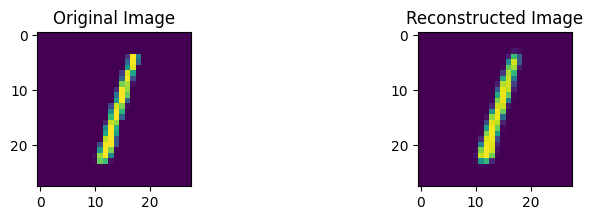

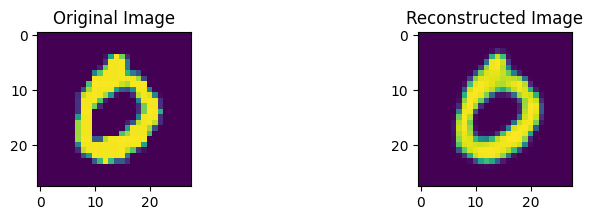

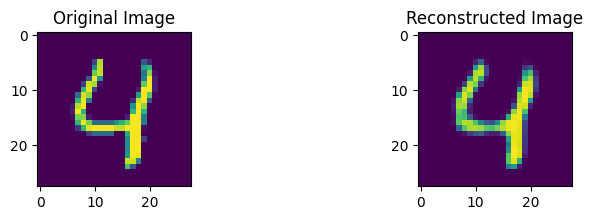

In [9]:
test_iter = iter(test_loader)
imgs, labels = next(test_iter)
imgs = imgs.to(device)

with torch.no_grad():
    outputs = autoencoder(imgs)

imgs = imgs.cpu().numpy()
outputs = outputs.cpu().numpy()

num_imgs = 5
for i in range(num_imgs):
    original_image = np.transpose(imgs[i], (1, 2, 0))
    reconstructed_image = np.transpose(outputs[i], (1, 2, 0))


    # Mostrar la imagen original
    plt.figure(figsize=(9, 2))
    plt.subplot(1, 2, 1)
    plt.imshow(original_image, interpolation='none')
    plt.title('Original Image')

    # Mostrar la imagen reconstruida
    plt.subplot(1, 2, 2)
    plt.imshow(reconstructed_image, interpolation='none')
    plt.title('Reconstructed Image')

    plt.show()

### ¿Y si restringimos más la red?

In [10]:
class Autoencoder2(nn.Module):
    def __init__(self):
        super(Autoencoder2, self).__init__()

        # Encoder
        self.enc_conv1 = nn.Conv2d(1, 16, 3, padding=1, stride=1)  # entrada: 28x28x1 salida: 28x28x16
        self.pool1 = nn.MaxPool2d(2, 2)  # salida: 14x14x16
        self.enc_conv2 = nn.Conv2d(16, 16, 3, padding=1, stride=1)  # salida: 14x14x16
        self.pool2 = nn.MaxPool2d(2, 2)  # salida: 7x7x16
        self.enc_conv3 = nn.Conv2d(16, 1, 3, padding=1, stride=1)  # salida: 7x7x1

        # Decoder
        self.dec_conv1 = nn.ConvTranspose2d(1, 16, 2, stride=2)       # salida: 14x14x16
        self.dec_conv2 = nn.ConvTranspose2d(16, 16, 2, stride=2)      # salida: 28x28x16
        self.dec_conv3 = nn.Conv2d(16, 1, 3, padding=1)               # salida: 28x28x1

    def forward_encoder(self, x):
        x = F.relu(self.enc_conv1(x))
        x = self.pool1(x)
        x = F.relu(self.enc_conv2(x))
        x = self.pool2(x)
        x = F.relu(self.enc_conv3(x))
        return x

    def forward_decoder(self, x):
        x = F.relu(self.dec_conv1(x))
        x = F.relu(self.dec_conv2(x))
        x = torch.sigmoid(self.dec_conv3(x))  # salida: 28x28x1, aplicamos sigmoid para tener valores entre [0, 1]
        return x

    def forward(self, x):
        x = self.forward_encoder(x)
        x = self.forward_decoder(x)
        return x

autoencoder2 = Autoencoder2().to(device)

In [11]:
criterion = nn.MSELoss().to(device)
optimizer = torch.optim.SGD(autoencoder2.parameters(), lr=0.02, momentum=0.9)

In [ ]:
num_epochs = 50

for epoch in range(num_epochs):
  train_loss = []
  val_loss = []

  for data in train_loader:
    imgs, labels = data
    imgs = imgs.to(device)
    outputs = autoencoder2(imgs)
    loss = criterion(outputs, imgs) # Comparar la imagen reconstruida con la original
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    train_loss.append(loss.item() * imgs.size(0))


  with torch.no_grad():
    for data_val in val_loader:
      imgs_val, labels_val = data_val
      imgs_val = imgs_val.to(device)
      outputs_val = autoencoder2(imgs_val)
      loss_val = criterion(outputs_val, imgs_val) # Comparar la imagen reconstruida con la original
      val_loss.append(loss_val.item() * imgs_val.size(0))




  print(f'Epoch: {epoch+1}, Train Loss: {np.mean(train_loss):.4f}, Val Loss: {np.mean(val_loss):.4f}')

Epoch: 1, Train Loss: 6.3515, Val Loss: 6.1331
Epoch: 2, Train Loss: 6.1113, Val Loss: 6.0755
Epoch: 3, Train Loss: 6.0554, Val Loss: 6.0210
Epoch: 4, Train Loss: 6.0052, Val Loss: 5.9771
Epoch: 5, Train Loss: 5.9691, Val Loss: 5.9488


Visualizamos en imágenes de train

In [ ]:
import matplotlib.pyplot as plt

# Cambiar el modelo a modo de evaluación
autoencoder2.eval()

train_iter = iter(train_loader)
imgs, labels = next(train_iter)
imgs = imgs.to(device)

with torch.no_grad():
    outputs = autoencoder2(imgs)
    latent_space = autoencoder2.forward_encoder(imgs)

imgs = imgs.cpu().numpy()
outputs = outputs.cpu().numpy()

num_imgs = 5
for i in range(num_imgs):
    original_image = np.transpose(imgs[i], (1, 2, 0))
    reconstructed_image = np.transpose(outputs[i], (1, 2, 0))


    # Mostrar la imagen original
    plt.figure(figsize=(9, 2))
    plt.subplot(1, 2, 1)
    plt.imshow(original_image, interpolation='none')
    plt.title('Original Image')

    # Mostrar la imagen reconstruida
    plt.subplot(1, 2, 2)
    plt.imshow(reconstructed_image, interpolation='none')
    plt.title('Reconstructed Image')

    plt.show()

    print(latent_space[i].shape)
    print(latent_space[i].view(1, -1))


Visualizamos en imágenes de test

In [ ]:

test_iter = iter(test_loader)
imgs, labels = next(test_iter)
imgs = imgs.to(device)

with torch.no_grad():
    outputs = autoencoder2(imgs)

imgs = imgs.cpu().numpy()
outputs = outputs.cpu().numpy()

num_imgs = 5
for i in range(num_imgs):
    original_image = np.transpose(imgs[i], (1, 2, 0))
    reconstructed_image = np.transpose(outputs[i], (1, 2, 0))


    # Mostrar la imagen original
    plt.figure(figsize=(9, 2))
    plt.subplot(1, 2, 1)
    plt.imshow(original_image, interpolation='none')
    plt.title('Original Image')

    # Mostrar la imagen reconstruida
    plt.subplot(1, 2, 2)
    plt.imshow(reconstructed_image, interpolation='none')
    plt.title('Reconstructed Image')

    plt.show()

## 2da parte - jugando con el espacio latente

In [ ]:
# Probemos valores random en el espacio latente y ver qué imagen reconstruye

latent_space = torch.randn(20, 1, 7, 7).to(device) * 4 # 5 imágenes, 1 canal, 7x7
print(latent_space.shape)

with torch.no_grad():
    outputs = autoencoder2.forward_decoder(latent_space)

outputs = outputs.cpu().numpy()

num_imgs = 20
for i in range(num_imgs):
    reconstructed_image = np.transpose(outputs[i], (1, 2, 0))

    # Desnormalizar las imágenes
    reconstructed_image = reconstructed_image * 0.5 + 0.5

    # Asegurarse de que los valores estén entre 0 y 1
    reconstructed_image = np.clip(reconstructed_image, 0, 1)

    # Mostrar la imagen reconstruida
    plt.figure(figsize=(9, 2))
    plt.imshow(reconstructed_image, interpolation='none')
    plt.title('Reconstructed Image')

    plt.show()


Probemos ahora partir del espacio latente de una imagen real y luego variar aleatoriamente estos valores.

In [ ]:
# Probemos ahora partir del espacio latente de un numero y modificar sus valores de forma random
imgs = next(iter(test_loader))[0]
imgs = imgs.cpu()

original_image = np.transpose(imgs.numpy()[0], (1, 2, 0))
plt.imshow(original_image, interpolation='none')
plt.show()


with torch.no_grad():
    latent_spaces = autoencoder2.forward_encoder(imgs.to(device))
    original_latent = latent_spaces[0]

    for i in range(10):
        # Generar ruido aleatorio
        noise = torch.randn_like(original_latent) * 4  # Ajusta la magnitud del ruido según necesites

        # Modificar el vector latente original con el ruido
        modified_latent = original_latent + noise

        # Decodificar el vector latente modificado para obtener una imagen
        decoded_image = autoencoder2.forward_decoder(modified_latent.unsqueeze(0)).cpu()

        # Preparar y mostrar la imagen
        decoded_image_np = np.transpose(decoded_image.numpy()[0], (1, 2, 0))
        plt.imshow(decoded_image_np, interpolation='none')
        plt.title(f"Modified Image {i+1}")
        plt.show()